FOR the bottleneck at 16 #(128 - 16 )
Loss = 0.0113

Epoch 1/10 , Loss : 0.0260
Epoch 2/10 , Loss : 0.0158
Epoch 3/10 , Loss : 0.0139
Epoch 4/10 , Loss : 0.0129
Epoch 5/10 , Loss : 0.0124
Epoch 6/10 , Loss : 0.0120
Epoch 7/10 , Loss : 0.0117
Epoch 8/10 , Loss : 0.0116
Epoch 9/10 , Loss : 0.0114
Epoch 10/10 , Loss : 0.0113


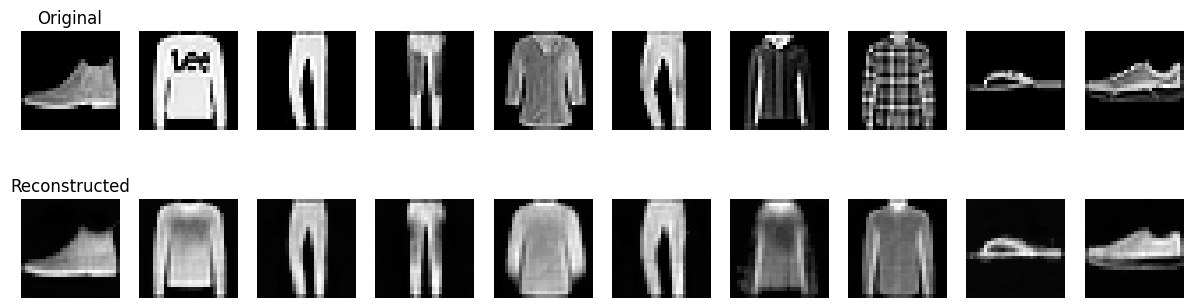

In [28]:
import torch as ts
import torch.nn as nn

# data transformion setup
from torchvision import transforms

trans = transforms.ToTensor()
"""tran = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5) , (0.5))
])"""

# data org
from torchvision.datasets import FashionMNIST

train_dataset = FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=trans
)

test_dataset = FashionMNIST(
    root= "./data",
    train=False ,
    download=True,
    transform=trans
)

# dataloader

from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)

# model
class AutoEcoder(nn.Module):

  def __init__(self):
    super(AutoEcoder, self).__init__()

  # encoder
    self.encoder_net = nn.Sequential(
        nn.Linear(28*28, 256),
        nn.ReLU(),
        nn.Linear(256 , 128),
        nn.ReLU(),
        nn.Linear(128 , 16)
        #nn.ReLU(),
        #nn.Linear(64 , 32)
    )

  # decoder
    self.decoder_net = nn.Sequential(
        #nn.Linear(32 , 64),
        #nn.ReLU(),
        nn.Linear(16 , 128),
        nn.ReLU(),
        nn.Linear(128 , 256),
        nn.ReLU(),
        nn.Linear(256 , 28*28),
        #nn.Tanh(),
        nn.LeakyReLU()
        #nn.Sigmoid()
    )

  def encoder(self , x):
    x = x.view(-1 , 28*28)
    x = self.encoder_net(x)
    return x

  def decoder(self , x):
    reconstructed = self.decoder_net(x)
    return reconstructed

  def forward(self , x):
    encoded = self.encoder(x)
    reconstructed = self.decoder(encoded)
    return reconstructed

model = AutoEcoder()
criterion = nn.MSELoss()
optimizer = ts.optim.Adam(model.parameters())

# training
epoches = 10

for epoch in range(epoches) :

  running_loss = 0.00
  for images , label in train_loader:
    images = images.view(-1 , 28*28)
    optimizer.zero_grad()
    output = model(images)
    loss = criterion(output , images)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  epoch_loss = running_loss / len(train_loader)
  print(f"Epoch {epoch+1}/{epoches} , Loss : {epoch_loss:.4f}")

# test

images = next(iter(test_loader))[0]
with ts.no_grad():
  reconstructed = model(images)

# visualization

from matplotlib import pyplot as plt

fig , axes = plt.subplots(2 , 10 , figsize=(15,4))

for i in range(10):
  axes[0 , i].imshow(
      images[i].squeeze() ,
      cmap = "gray" )
  axes[0 , i].axis("off")

  axes[1 , i].imshow(
      reconstructed[i].view(28 , 28),
      cmap = "gray" )
  axes[1 , i].axis("off")
axes[0 ,0].set_title("Original")
axes[1 ,0].set_title("Reconstructed")

plt.show()



FOR the bottleneck at 32 #(128 - 32 )
Loss = 0.0098

Epoch 1/10 , Loss : 0.0264
Epoch 2/10 , Loss : 0.0157
Epoch 3/10 , Loss : 0.0135
Epoch 4/10 , Loss : 0.0123
Epoch 5/10 , Loss : 0.0116
Epoch 6/10 , Loss : 0.0111
Epoch 7/10 , Loss : 0.0107
Epoch 8/10 , Loss : 0.0103
Epoch 9/10 , Loss : 0.0101
Epoch 10/10 , Loss : 0.0098


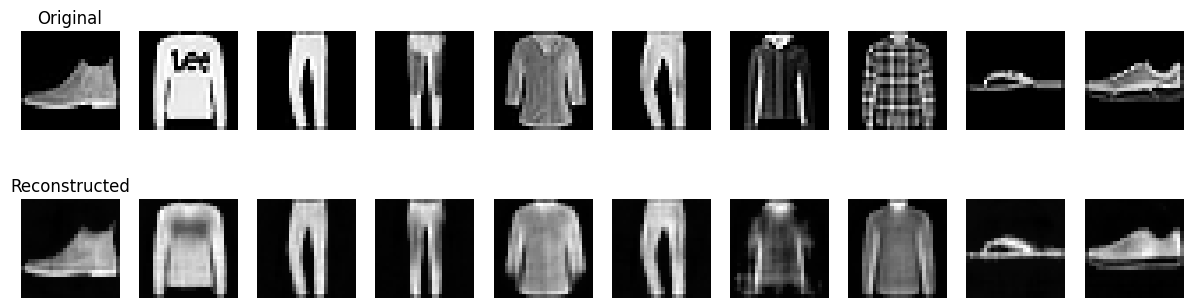

In [29]:
import torch as ts
import torch.nn as nn

# data transformion setup
from torchvision import transforms

trans = transforms.ToTensor()
"""tran = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5) , (0.5))
])"""

# data org
from torchvision.datasets import FashionMNIST

train_dataset = FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=trans
)

test_dataset = FashionMNIST(
    root= "./data",
    train=False ,
    download=True,
    transform=trans
)

# dataloader

from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)

# model
class AutoEcoder(nn.Module):

  def __init__(self):
    super(AutoEcoder, self).__init__()

  # encoder
    self.encoder_net = nn.Sequential(
        nn.Linear(28*28, 256),
        nn.ReLU(),
        nn.Linear(256 , 128),
        nn.ReLU(),
        nn.Linear(128 , 32)
        #nn.ReLU(),
        #nn.Linear(64 , 32)
    )

  # decoder
    self.decoder_net = nn.Sequential(
        #nn.Linear(32 , 64),
        #nn.ReLU(),
        nn.Linear(32 , 128),
        nn.ReLU(),
        nn.Linear(128 , 256),
        nn.ReLU(),
        nn.Linear(256 , 28*28),
        #nn.Tanh(),
        nn.LeakyReLU()
        #nn.Sigmoid()
    )

  def encoder(self , x):
    x = x.view(-1 , 28*28)
    x = self.encoder_net(x)
    return x

  def decoder(self , x):
    reconstructed = self.decoder_net(x)
    return reconstructed

  def forward(self , x):
    encoded = self.encoder(x)
    reconstructed = self.decoder(encoded)
    return reconstructed

model = AutoEcoder()
criterion = nn.MSELoss()
optimizer = ts.optim.Adam(model.parameters())

# training
epoches = 10

for epoch in range(epoches) :

  running_loss = 0.00
  for images , label in train_loader:
    images = images.view(-1 , 28*28)
    optimizer.zero_grad()
    output = model(images)
    loss = criterion(output , images)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  epoch_loss = running_loss / len(train_loader)
  print(f"Epoch {epoch+1}/{epoches} , Loss : {epoch_loss:.4f}")

# test

images = next(iter(test_loader))[0]
with ts.no_grad():
  reconstructed = model(images)

# visualization

from matplotlib import pyplot as plt

fig , axes = plt.subplots(2 , 10 , figsize=(15,4))

for i in range(10):
  axes[0 , i].imshow(
      images[i].squeeze() ,
      cmap = "gray" )
  axes[0 , i].axis("off")

  axes[1 , i].imshow(
      reconstructed[i].view(28 , 28),
      cmap = "gray" )
  axes[1 , i].axis("off")
axes[0 ,0].set_title("Original")
axes[1 ,0].set_title("Reconstructed")

plt.show()



FOR the bottleneck at 64 #(128 - 64 )
Loss = 0.0091

Epoch 1/10 , Loss : 0.0265
Epoch 2/10 , Loss : 0.0153
Epoch 3/10 , Loss : 0.0131
Epoch 4/10 , Loss : 0.0119
Epoch 5/10 , Loss : 0.0112
Epoch 6/10 , Loss : 0.0106
Epoch 7/10 , Loss : 0.0101
Epoch 8/10 , Loss : 0.0098
Epoch 9/10 , Loss : 0.0095
Epoch 10/10 , Loss : 0.0092


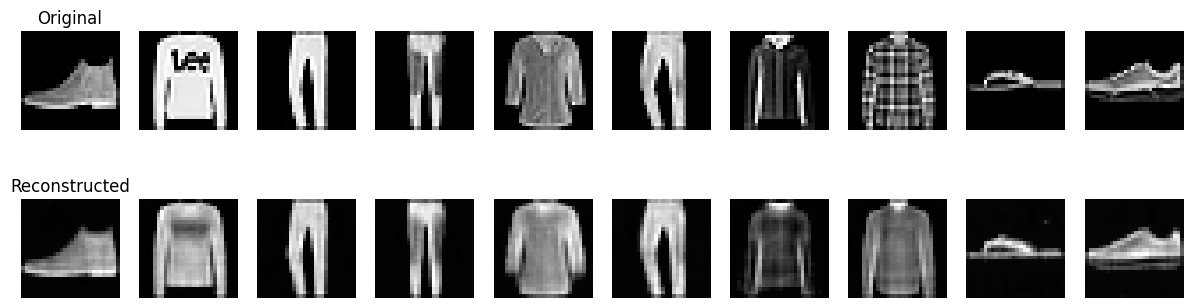

In [30]:
import torch as ts
import torch.nn as nn

# data transformion setup
from torchvision import transforms

trans = transforms.ToTensor()
"""tran = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5) , (0.5))
])"""

# data org
from torchvision.datasets import FashionMNIST

train_dataset = FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=trans
)

test_dataset = FashionMNIST(
    root= "./data",
    train=False ,
    download=True,
    transform=trans
)

# dataloader

from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)

# model
class AutoEcoder(nn.Module):

  def __init__(self):
    super(AutoEcoder, self).__init__()

  # encoder
    self.encoder_net = nn.Sequential(
        nn.Linear(28*28, 256),
        nn.ReLU(),
        nn.Linear(256 , 128),
        nn.ReLU(),
        nn.Linear(128 , 64)
        #nn.ReLU(),
        #nn.Linear(64 , 32)
    )

  # decoder
    self.decoder_net = nn.Sequential(
        #nn.Linear(32 , 64),
        #nn.ReLU(),
        nn.Linear(64 , 128),
        nn.ReLU(),
        nn.Linear(128 , 256),
        nn.ReLU(),
        nn.Linear(256 , 28*28),
        #nn.Tanh(),
        nn.LeakyReLU()
        #nn.Sigmoid()
    )

  def encoder(self , x):
    x = x.view(-1 , 28*28)
    x = self.encoder_net(x)
    return x

  def decoder(self , x):
    reconstructed = self.decoder_net(x)
    return reconstructed

  def forward(self , x):
    encoded = self.encoder(x)
    reconstructed = self.decoder(encoded)
    return reconstructed

model = AutoEcoder()
criterion = nn.MSELoss()
optimizer = ts.optim.Adam(model.parameters())

# training
epoches = 10

for epoch in range(epoches) :

  running_loss = 0.00
  for images , label in train_loader:
    images = images.view(-1 , 28*28)
    optimizer.zero_grad()
    output = model(images)
    loss = criterion(output , images)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  epoch_loss = running_loss / len(train_loader)
  print(f"Epoch {epoch+1}/{epoches} , Loss : {epoch_loss:.4f}")

# test

images = next(iter(test_loader))[0]
with ts.no_grad():
  reconstructed = model(images)

# visualization

from matplotlib import pyplot as plt

fig , axes = plt.subplots(2 , 10 , figsize=(15,4))

for i in range(10):
  axes[0 , i].imshow(
      images[i].squeeze() ,
      cmap = "gray" )
  axes[0 , i].axis("off")

  axes[1 , i].imshow(
      reconstructed[i].view(28 , 28),
      cmap = "gray" )
  axes[1 , i].axis("off")
axes[0 ,0].set_title("Original")
axes[1 ,0].set_title("Reconstructed")

plt.show()

